# Single-Layer Geometry Deep Dive from Mongo

This notebook reuses the same Mongo scan query as `geometry_separation_from_mongo.ipynb`, but dives into one configurable layer.

It includes:
- stronger per-layer probes on raw and PCA-compressed features
- within-class subcluster analysis with KMeans and GMM
- discriminative direction analysis and margin distributions
- token-pooling and token-position probe sweeps for the chosen layer
- class-conditional subspace and cross-reconstruction analysis
- whole-layer PCA visualizations for the selected layer

In [1]:
import os
import sys
import tempfile

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score, accuracy_score, silhouette_score
from sklearn.metrics import adjusted_rand_score

from neuralsignal.backend.ns_backend import NSBackend
from neuralsignal.core.modules.neuralsignal_config import sdk_config

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Same Mongo / dataset query pattern as geometry_separation_from_mongo.ipynb
APPLICATION_NAME = "HaluBench"
SUB_APPLICATION_NAME = "GranularAttentioAndWO"

# APPLICATION_NAME = "redis"
# SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

BASE_QUERY = {}
GROUND_TRUTH_0_QUERY = {"ground_truth": {"$in": [0, "0", False]}}
GROUND_TRUTH_1_QUERY = {"ground_truth": {"$in": [1, "1", True]}}

LAYER_NAME_FILTER = "SelfAttention.o"   # or "DenseReluDense.wo"
TARGET_LAYER_INDEX = 21                  # vary this layer index

MAX_SCANS_PER_CLASS = 50
RANDOM_STATE = 7
CV_FOLDS = 5
PCA_COMPONENTS = 16
TOP_DIMS_TO_SHOW = 20
MAX_TOKEN_POSITIONS = 6
BOOTSTRAP_ROUNDS = 64

LABEL_0 = "ground_truth=0"
LABEL_1 = "ground_truth=1"

In [3]:
backend_cfg = sdk_config.get_backend_config().copy()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

def merged_query(*parts):
    out = {}
    for p in parts:
        out.update(p)
    return out

def load_scans_by_query(ns_backend, query, limit=0):
    cursor = ns_backend.query(query)
    if limit and limit > 0:
        cursor = cursor.limit(limit)
    scans = []
    skipped = 0
    for doc in cursor:
        try:
            scans.append(ns_backend.deserialize_scan(doc))
        except Exception:
            skipped += 1
    return scans, skipped

def get_mongo_backend(ns_backend):
    backend = ns_backend.backend
    if hasattr(backend, "col"):
        return backend
    if hasattr(backend, "mng"):
        return backend.mng
    raise TypeError("Configured backend does not expose a Mongo collection.")

query_0 = merged_query(BASE_QUERY, GROUND_TRUTH_0_QUERY)
query_1 = merged_query(BASE_QUERY, GROUND_TRUTH_1_QUERY)

group_0, skipped_0 = load_scans_by_query(be, query_0, MAX_SCANS_PER_CLASS)
group_1, skipped_1 = load_scans_by_query(be, query_1, MAX_SCANS_PER_CLASS)

mongo_backend = get_mongo_backend(be)
print(f"Mongo db         : {mongo_backend.db.name}")
print(f"Mongo collection : {mongo_backend.col.name}")
print(f"{LABEL_0}: loaded {len(group_0)} scans  (skipped {skipped_0})")
print(f"{LABEL_1}: loaded {len(group_1)} scans  (skipped {skipped_1})")

Mongo db         : HaluBench
Mongo collection : GranularAttentioAndWO
ground_truth=0: loaded 50 scans  (skipped 0)
ground_truth=1: loaded 50 scans  (skipped 0)


In [4]:
rng = np.random.default_rng(RANDOM_STATE)

def get_matching_layers(scan, layer_name_filter):
    matches = []
    for layer_id in scan["layer_order"]:
        layer_name = scan["layer_id_to_name"][layer_id]
        if layer_name_filter in layer_name:
            matches.append((layer_id, layer_name, f"L{len(matches):02d}"))
    return matches

def choose_reference_layers(group_a, group_b, layer_name_filter):
    for scan in list(group_a) + list(group_b):
        matches = get_matching_layers(scan, layer_name_filter)
        if matches:
            return matches
    raise ValueError("No matching layers found in either class.")

def extract_layer_tensor(scan, layer_id):
    t = scan["outputs"][layer_id].float().cpu().numpy()
    if t.ndim == 1:
        t = t[None, :]
    if t.ndim != 2:
        raise ValueError(f"Expected 2D layer tensor, got shape {t.shape}")
    return t

reference_layers = choose_reference_layers(group_0, group_1, LAYER_NAME_FILTER)
target_layer_id, target_layer_name, target_layer_label = reference_layers[TARGET_LAYER_INDEX]
print(f"Target layer index : {TARGET_LAYER_INDEX}")
print(f"Target layer label : {target_layer_label}")
print(f"Target layer name  : {target_layer_name}")

Target layer index : 21
Target layer label : L21
Target layer name  : encoder.T5Block.T5LayerSelfAttention.SelfAttention.o


In [5]:
def build_layer_dataset(scans, layer_id):
    mats = []
    ids = []
    dropped = 0
    hidden_dim = None
    for scan in scans:
        try:
            mat = extract_layer_tensor(scan, layer_id)
            if hidden_dim is None:
                hidden_dim = mat.shape[1]
            if mat.shape[1] != hidden_dim:
                dropped += 1
                continue
            mats.append(mat)
            ids.append(str(scan.get("_id", len(ids))))
        except Exception:
            dropped += 1
    return mats, ids, dropped

layer_mats_0, ids0, dropped0 = build_layer_dataset(group_0, target_layer_id)
layer_mats_1, ids1, dropped1 = build_layer_dataset(group_1, target_layer_id)
all_mats = layer_mats_0 + layer_mats_1
all_ids = ids0 + ids1
y = np.array([0] * len(layer_mats_0) + [1] * len(layer_mats_1))

max_seq_len = max(mat.shape[0] for mat in all_mats)
hidden_dim = all_mats[0].shape[1]
print(f"Class-0 valid scans : {len(layer_mats_0)}  dropped {dropped0}")
print(f"Class-1 valid scans : {len(layer_mats_1)}  dropped {dropped1}")
print(f"Max token length    : {max_seq_len}")
print(f"Hidden dim          : {hidden_dim}")

Class-0 valid scans : 50  dropped 0
Class-1 valid scans : 50  dropped 0
Max token length    : 610
Hidden dim          : 1024


In [6]:
def pool_tokens(mat, mode):
    if mode == "first":
        return mat[0]
    if mode == "last":
        return mat[-1]
    if mode == "middle":
        return mat[len(mat) // 2]
    if mode == "penultimate":
        return mat[-2] if len(mat) >= 2 else mat[-1]
    if mode == "mean":
        return mat.mean(axis=0)
    if mode == "max":
        return mat.max(axis=0)
    raise ValueError(f"Unknown pooling mode: {mode}")

def relative_token(mat, rel_pos):
    idx = int(round(rel_pos * (len(mat) - 1)))
    return mat[idx]

def build_feature_matrix(mats, feature_spec):
    rows = []
    for mat in mats:
        kind = feature_spec["kind"]
        if kind == "pool":
            rows.append(pool_tokens(mat, feature_spec["mode"]))
        elif kind == "relative_token":
            rows.append(relative_token(mat, feature_spec["rel_pos"]))
        elif kind == "flatten":
            padded = np.zeros((feature_spec["pad_to"], mat.shape[1]), dtype=mat.dtype)
            n = min(len(mat), feature_spec["pad_to"])
            padded[:n] = mat[:n]
            rows.append(padded.reshape(-1))
        else:
            raise ValueError(f"Unknown feature kind: {kind}")
    return np.stack(rows, axis=0)

pool_specs = [
    {"name": "first", "kind": "pool", "mode": "first"},
    {"name": "middle", "kind": "pool", "mode": "middle"},
    {"name": "penultimate", "kind": "pool", "mode": "penultimate"},
    {"name": "last", "kind": "pool", "mode": "last"},
    {"name": "mean", "kind": "pool", "mode": "mean"},
    {"name": "max", "kind": "pool", "mode": "max"},
]

relative_positions = np.linspace(0.0, 1.0, MAX_TOKEN_POSITIONS)
token_specs = [
    {"name": f"rel_{p:.2f}", "kind": "relative_token", "rel_pos": float(p)}
    for p in relative_positions
]

sequence_spec = {"name": f"flatten_first_{max_seq_len}", "kind": "flatten", "pad_to": max_seq_len}

feature_sets = pool_specs + token_specs + [sequence_spec]
feature_matrices = {spec["name"]: build_feature_matrix(all_mats, spec) for spec in feature_sets}
list(feature_matrices.keys())

['first',
 'middle',
 'penultimate',
 'last',
 'mean',
 'max',
 'rel_0.00',
 'rel_0.20',
 'rel_0.40',
 'rel_0.60',
 'rel_0.80',
 'rel_1.00',
 'flatten_first_610']

In [19]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def model_catalog(feature_dim, pca_components):
    k = max(1, min(pca_components, feature_dim, len(y) - 1))
    return {
        "logreg_raw": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)),
        ]),
        "logreg_pca": Pipeline([
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
            ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)),
        ]),
        "linear_svm": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LinearSVC(C=1.0, max_iter=10000, random_state=RANDOM_STATE)),
        ]),
        "random_forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    }

def evaluate_models(X, y_vec, pca_components=PCA_COMPONENTS):
    rows = []
    for name, model in model_catalog(X.shape[1], pca_components).items():
        scores = cross_validate(
            model,
            X,
            y_vec,
            cv=cv,
            scoring=["roc_auc", "accuracy"],
            return_train_score=False,
            error_score="raise",
        )
        rows.append({
            "model": name,
            "auc_mean": float(scores["test_roc_auc"].mean()),
            "auc_std": float(scores["test_roc_auc"].std(ddof=1)),
            "acc_mean": float(scores["test_accuracy"].mean()),
            "acc_std": float(scores["test_accuracy"].std(ddof=1)),
        })
    return pd.DataFrame(rows).sort_values("auc_mean", ascending=False)

raw_probe_results = evaluate_models(feature_matrices["last"], y)
raw_probe_results

,model,auc_mean,auc_std,acc_mean,acc_std
3,random_forest,0.858,0.088713,0.75,0.086603
1,logreg_pca,0.826,0.039115,0.74,0.065192
0,logreg_raw,0.810,0.102713,0.75,0.086603
2,linear_svm,0.800,0.113358,0.75,0.086603


In [20]:
token_probe_rows = []
for spec in pool_specs + token_specs:
    X_spec = feature_matrices[spec["name"]]
    result = evaluate_models(X_spec, y).iloc[0].to_dict()
    token_probe_rows.append({"feature": spec["name"], **result})

token_probe_df = pd.DataFrame(token_probe_rows).sort_values("auc_mean", ascending=False)
token_probe_df

,feature,model,auc_mean,auc_std,acc_mean,acc_std
0,first,logreg_raw,0.918,0.058052,0.81,0.089443
6,rel_0.00,logreg_raw,0.918,0.058052,0.81,0.089443
4,mean,linear_svm,0.910,0.030000,0.79,0.082158
5,max,linear_svm,0.906,0.053198,0.81,0.096177
2,penultimate,logreg_pca,0.878,0.085264,0.81,0.089443
3,last,random_forest,0.858,0.088713,0.75,0.086603
11,rel_1.00,random_forest,0.858,0.088713,0.75,0.086603
10,rel_0.80,logreg_raw,0.836,0.120955,0.75,0.145774
8,rel_0.40,random_forest,0.796,0.131453,0.67,0.115109
9,rel_0.60,logreg_raw,0.766,0.040988,0.68,0.044721


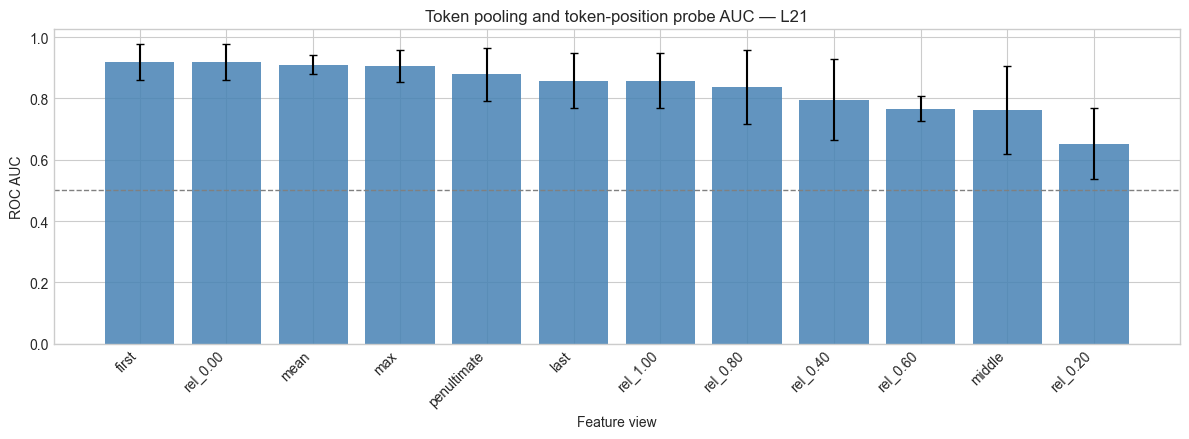

In [21]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(token_probe_df["feature"], token_probe_df["auc_mean"], color="steelblue", alpha=0.85)
ax.errorbar(token_probe_df["feature"], token_probe_df["auc_mean"], yerr=token_probe_df["auc_std"], fmt="none", ecolor="black", capsize=3)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Token pooling and token-position probe AUC — {target_layer_label}")
ax.set_ylabel("ROC AUC")
ax.set_xlabel("Feature view")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Best feature view: first


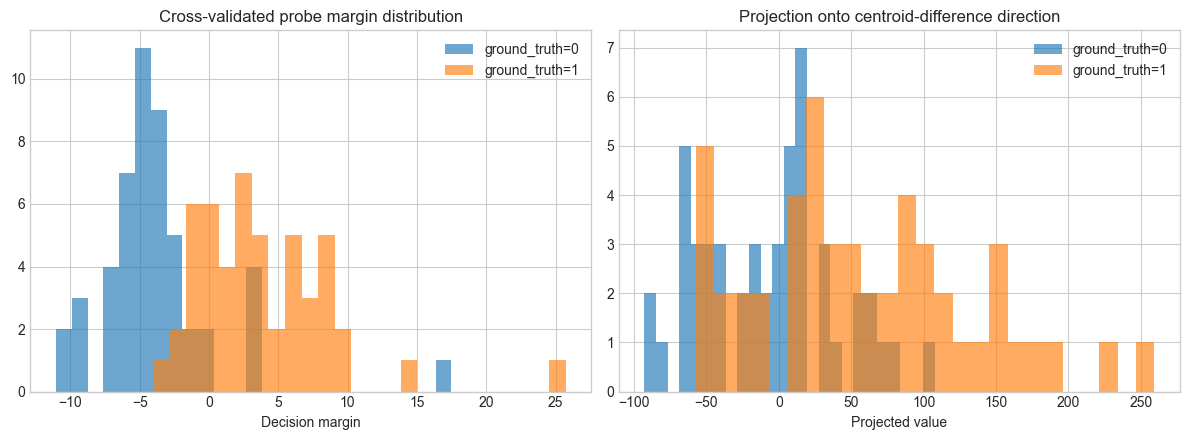

,dim,probe_coef,centroid_diff
0,515,-0.221876,-1.759090
1,762,0.211254,2.795263
2,720,-0.202648,-1.563705
3,786,-0.201092,-3.481232
4,976,-0.189291,-1.777464
5,249,-0.166203,-0.595528
6,312,-0.164638,-1.205427
7,180,-0.163207,-1.348820
8,629,0.160742,-0.504755
9,267,-0.160131,-1.336135


In [22]:
best_feature_name = token_probe_df.iloc[0]["feature"]
X_best = feature_matrices[best_feature_name]
print(f"Best feature view: {best_feature_name}")

probe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)),
])
margin_scores = cross_val_predict(probe, X_best, y, cv=cv, method="decision_function")
probe.fit(X_best, y)
coef = probe.named_steps["clf"].coef_[0]
top_dims = np.argsort(np.abs(coef))[::-1][:TOP_DIMS_TO_SHOW]

class0 = X_best[y == 0]
class1 = X_best[y == 1]
centroid_diff = class1.mean(axis=0) - class0.mean(axis=0)
centroid_direction = centroid_diff / max(np.linalg.norm(centroid_diff), 1e-12)
proj_centroid_dir = X_best @ centroid_direction

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(margin_scores[y == 0], bins=25, alpha=0.65, label=LABEL_0)
axes[0].hist(margin_scores[y == 1], bins=25, alpha=0.65, label=LABEL_1)
axes[0].set_title("Cross-validated probe margin distribution")
axes[0].set_xlabel("Decision margin")
axes[0].legend()

axes[1].hist(proj_centroid_dir[y == 0], bins=25, alpha=0.65, label=LABEL_0)
axes[1].hist(proj_centroid_dir[y == 1], bins=25, alpha=0.65, label=LABEL_1)
axes[1].set_title("Projection onto centroid-difference direction")
axes[1].set_xlabel("Projected value")
axes[1].legend()
plt.tight_layout()
plt.show()

direction_df = pd.DataFrame({
    "dim": top_dims,
    "probe_coef": coef[top_dims],
    "centroid_diff": centroid_diff[top_dims],
})
direction_df

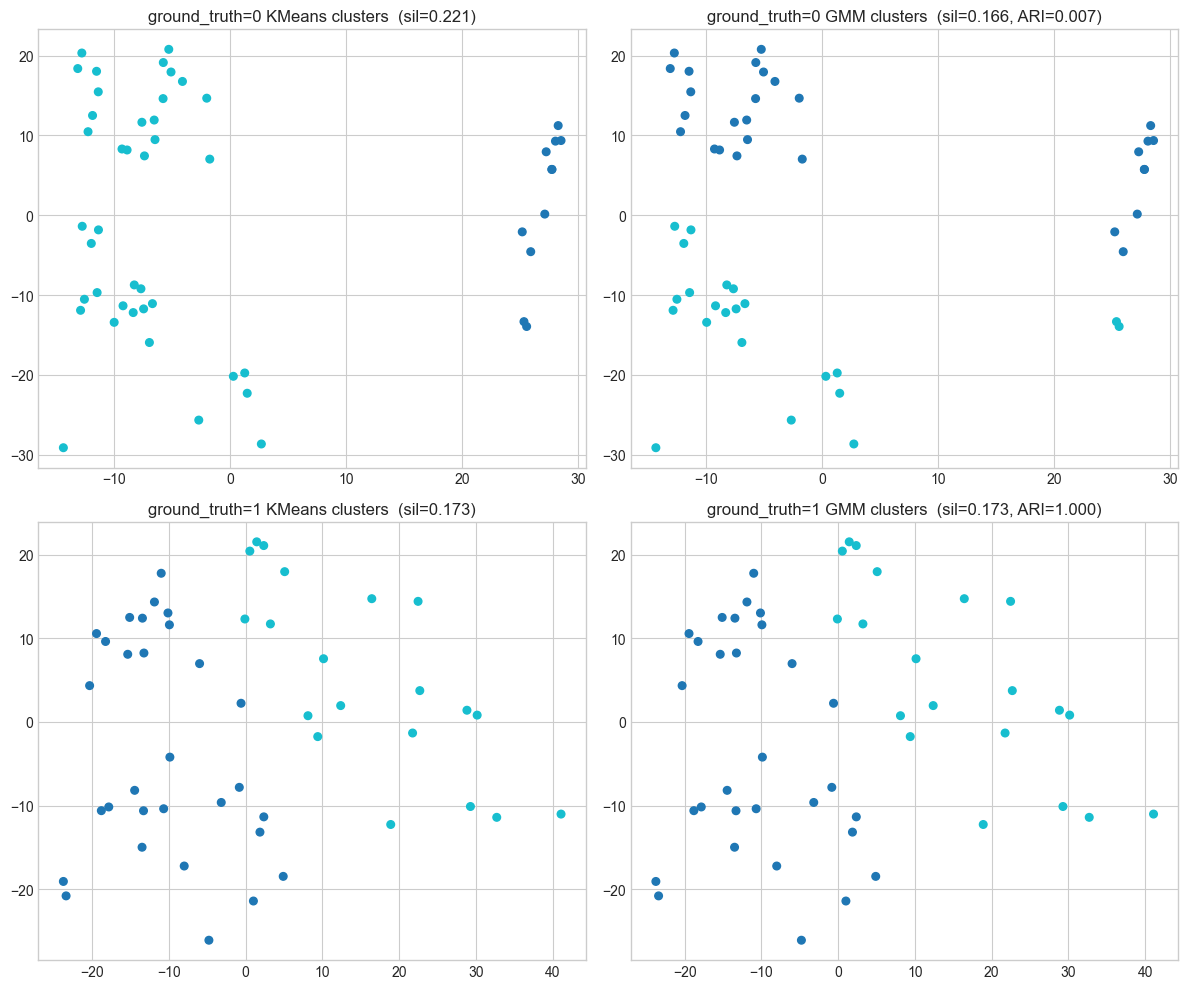

In [23]:
def cluster_view(X, name, n_clusters=2):
    scaled = StandardScaler().fit_transform(X).astype(np.float64)
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    proj = pca2.fit_transform(scaled)
    km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
    km_labels = km.fit_predict(scaled)
    gmm_labels = None
    for covariance_type in ["full", "diag"]:
        try:
            gmm = GaussianMixture(
                n_components=n_clusters,
                covariance_type=covariance_type,
                reg_covar=1e-5,
                n_init=5,
                random_state=RANDOM_STATE,
            )
            gmm_labels = gmm.fit_predict(scaled)
            break
        except ValueError:
            continue
    if gmm_labels is None:
        gmm_labels = np.zeros(len(scaled), dtype=int)
    sil_km = silhouette_score(scaled, km_labels) if len(np.unique(km_labels)) > 1 else np.nan
    sil_gmm = silhouette_score(scaled, gmm_labels) if len(np.unique(gmm_labels)) > 1 else np.nan
    ari = adjusted_rand_score(km_labels, gmm_labels) if len(np.unique(gmm_labels)) > 1 else np.nan
    return proj, km_labels, gmm_labels, sil_km, sil_gmm, ari

proj0, km0, gmm0, sil_km0, sil_gmm0, ari0 = cluster_view(X_best[y == 0], LABEL_0)
proj1, km1, gmm1, sil_km1, sil_gmm1, ari1 = cluster_view(X_best[y == 1], LABEL_1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].scatter(proj0[:, 0], proj0[:, 1], c=km0, cmap="tab10", s=30)
axes[0, 0].set_title(f"{LABEL_0} KMeans clusters  (sil={sil_km0:.3f})")
axes[0, 1].scatter(proj0[:, 0], proj0[:, 1], c=gmm0, cmap="tab10", s=30)
axes[0, 1].set_title(f"{LABEL_0} GMM clusters  (sil={sil_gmm0:.3f}, ARI={ari0:.3f})")
axes[1, 0].scatter(proj1[:, 0], proj1[:, 1], c=km1, cmap="tab10", s=30)
axes[1, 0].set_title(f"{LABEL_1} KMeans clusters  (sil={sil_km1:.3f})")
axes[1, 1].scatter(proj1[:, 0], proj1[:, 1], c=gmm1, cmap="tab10", s=30)
axes[1, 1].set_title(f"{LABEL_1} GMM clusters  (sil={sil_gmm1:.3f}, ARI={ari1:.3f})")
plt.tight_layout()
plt.show()

In [24]:
def pca_subspace(X, n_components):
    k = max(1, min(n_components, X.shape[0] - 1, X.shape[1]))
    pca = PCA(n_components=k, random_state=RANDOM_STATE).fit(X)
    return pca.mean_, pca.components_

def reconstruction_error(X, mean_vec, components):
    centered = X - mean_vec
    coeff = centered @ components.T
    recon = mean_vec + coeff @ components
    return np.linalg.norm(X - recon, axis=1)

def principal_angles_deg(components_a, components_b):
    svals = np.linalg.svd(components_a @ components_b.T, compute_uv=False)
    svals = np.clip(svals, -1.0, 1.0)
    return np.degrees(np.arccos(svals))

X0_best = X_best[y == 0]
X1_best = X_best[y == 1]
mean0, comp0 = pca_subspace(X0_best, PCA_COMPONENTS)
mean1, comp1 = pca_subspace(X1_best, PCA_COMPONENTS)
angles = principal_angles_deg(comp0, comp1)

err_00 = reconstruction_error(X0_best, mean0, comp0)
err_01 = reconstruction_error(X0_best, mean1, comp1)
err_11 = reconstruction_error(X1_best, mean1, comp1)
err_10 = reconstruction_error(X1_best, mean0, comp0)

subspace_summary = pd.DataFrame([
    {"group": LABEL_0, "own_subspace_err_mean": err_00.mean(), "other_subspace_err_mean": err_01.mean(), "ratio_other_over_own": err_01.mean() / max(err_00.mean(), 1e-12)},
    {"group": LABEL_1, "own_subspace_err_mean": err_11.mean(), "other_subspace_err_mean": err_10.mean(), "ratio_other_over_own": err_10.mean() / max(err_11.mean(), 1e-12)},
])
print(f"Mean principal angle: {angles.mean():.3f} degrees")
subspace_summary

Mean principal angle: 53.149 degrees


,group,own_subspace_err_mean,other_subspace_err_mean,ratio_other_over_own
0,ground_truth=0,32.357986,74.507912,2.302613
1,ground_truth=1,53.347137,98.915771,1.854191


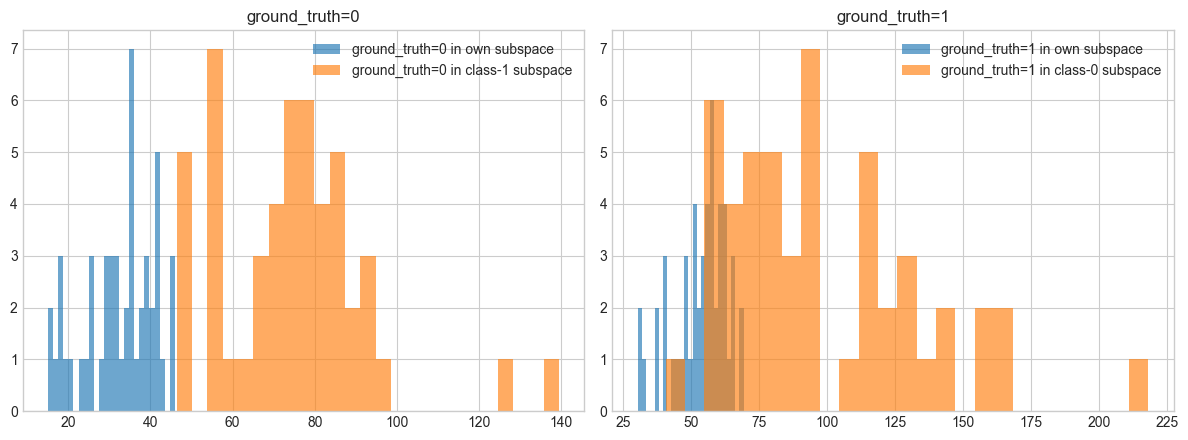

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(err_00, bins=25, alpha=0.65, label=f"{LABEL_0} in own subspace")
axes[0].hist(err_01, bins=25, alpha=0.65, label=f"{LABEL_0} in class-1 subspace")
axes[0].set_title(LABEL_0)
axes[0].legend()

axes[1].hist(err_11, bins=25, alpha=0.65, label=f"{LABEL_1} in own subspace")
axes[1].hist(err_10, bins=25, alpha=0.65, label=f"{LABEL_1} in class-0 subspace")
axes[1].set_title(LABEL_1)
axes[1].legend()
plt.tight_layout()
plt.show()

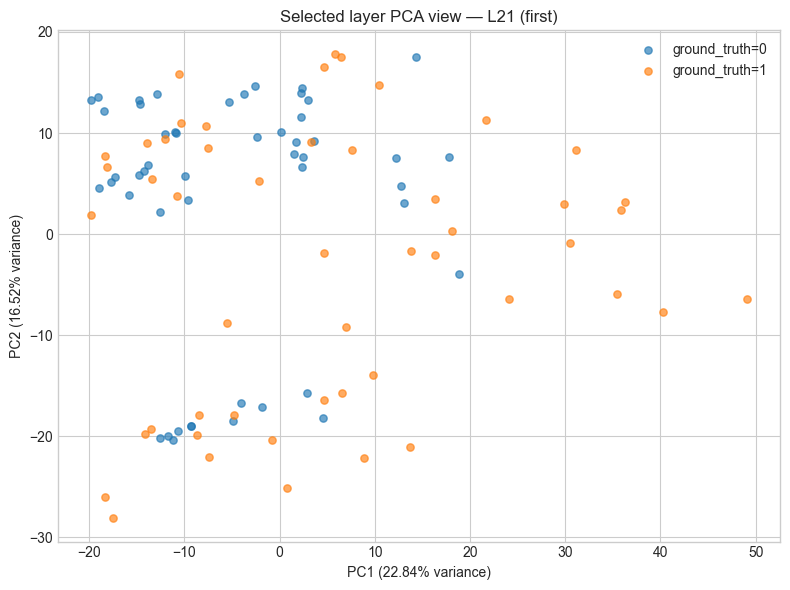

In [26]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
proj_best = pca2.fit_transform(StandardScaler().fit_transform(X_best))
var2 = pca2.explained_variance_ratio_ * 100.0

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(proj_best[y == 0, 0], proj_best[y == 0, 1], alpha=0.65, s=28, label=LABEL_0)
ax.scatter(proj_best[y == 1, 0], proj_best[y == 1, 1], alpha=0.65, s=28, label=LABEL_1)
ax.set_title(f"Selected layer PCA view — {target_layer_label} ({best_feature_name})")
ax.set_xlabel(f"PC1 ({var2[0]:.2f}% variance)")
ax.set_ylabel(f"PC2 ({var2[1]:.2f}% variance)")
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
summary = {
    "target_layer_index": TARGET_LAYER_INDEX,
    "target_layer_label": target_layer_label,
    "target_layer_name": target_layer_name,
    "best_feature_view": best_feature_name,
    "best_probe_model": raw_probe_results.iloc[0]["model"],
    "best_probe_auc": float(raw_probe_results.iloc[0]["auc_mean"]),
    "best_token_view_auc": float(token_probe_df.iloc[0]["auc_mean"]),
    "mean_principal_angle_deg": float(angles.mean()),
    "class0_cross_subspace_ratio": float(subspace_summary.iloc[0]["ratio_other_over_own"]),
    "class1_cross_subspace_ratio": float(subspace_summary.iloc[1]["ratio_other_over_own"]),
}
summary

{'target_layer_index': 21,
 'target_layer_label': 'L21',
 'target_layer_name': 'encoder.T5Block.T5LayerSelfAttention.SelfAttention.o',
 'best_feature_view': 'first',
 'best_probe_model': 'random_forest',
 'best_probe_auc': 0.858,
 'best_token_view_auc': 0.9179999999999999,
 'mean_principal_angle_deg': 53.14945983886719,
 'class0_cross_subspace_ratio': 2.302612781524658,
 'class1_cross_subspace_ratio': 1.8541908264160156}